# Applied Exercise 8 - Simple Linear Regression on Auto Dataset

#### Objective - perform a simple linear regression using the Auto dataset.

The goal is to predict `mpg` (miles per gallon) using the predictor variable: `horsepower` using the ordinary least squares (OLS) regression model.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

from ISLP import load_data

In [2]:
Auto = load_data("Auto")

Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [3]:
Auto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, chevrolet chevelle malibu to chevy s-10
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 27.6+ KB


In [4]:
X = sm.add_constant(Auto["horsepower"])
y = Auto["mpg"]

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           7.03e-81
Time:                        13:16:40   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.000      38.525      41.347
horsepower    -0.1578      0.006    -24.489      0.000      -0.171      -0.145
==============================================================================
Omnibus:                       16.432   Durbin-Watson:                   0.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.305
Skew:                           0.492   Prob(JB):                     0.000175
Kurtosis:                       3.299   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Interpretation of Regression Output

#### 1. Relationship between predictor and response

The p-value associated with horsepower indicates whether there is statistically significant evidence of a relationship between horsepower and mpg (<0.0001)

#### 2. Strength of relationship

The strength of the relationship can be assessed using R-squared ($R^2$). Here it is 0.606 which says around 60% of variability is explained by the model.

#### 3. Direction of relationship

The sign of the horsepower coefficient determines the direction. Here we have a negative coefficient → mpg decreases as horsepower increases.

In [5]:
new_car = pd.DataFrame({"const": [1], "horsepower": [98]})

prediction = model.get_prediction(new_car)
prediction.summary_frame(alpha=0.05)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,24.467077,0.251262,23.973079,24.961075,14.809396,34.124758


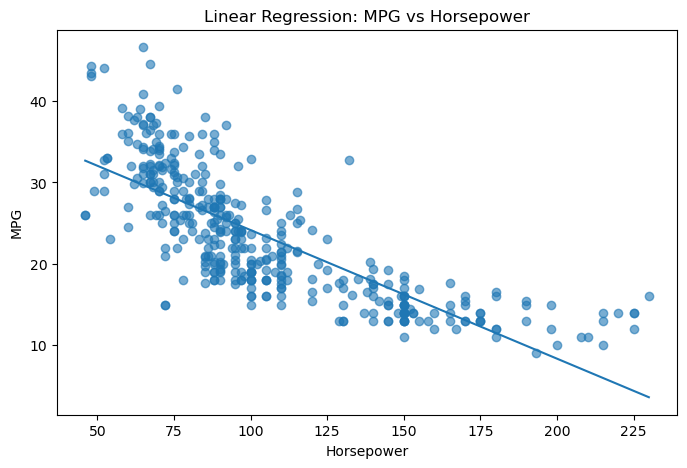

In [6]:
fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(
    Auto["horsepower"],
    Auto["mpg"],
    alpha=0.6
)

x_range = np.linspace(
    Auto["horsepower"].min(),
    Auto["horsepower"].max(),
    100
)

X_line = sm.add_constant(x_range)

y_pred = model.predict(X_line)

ax.plot(
    x_range,
    y_pred
)

ax.set_xlabel("Horsepower")
ax.set_ylabel("MPG")
ax.set_title("Linear Regression: MPG vs Horsepower")

plt.show()

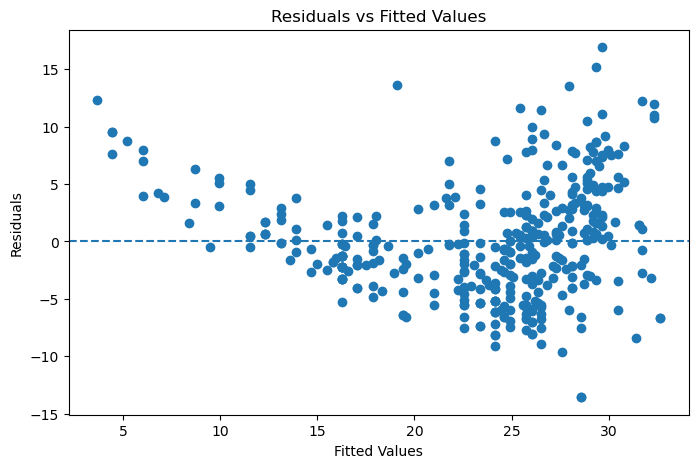

In [7]:
fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8,5))

plt.scatter(fitted, residuals)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs Fitted Values")

plt.show()

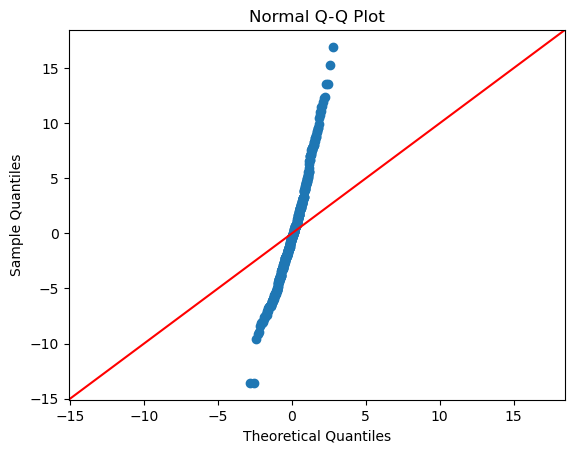

In [8]:
sm.qqplot(
    residuals,
    line="45"
)

plt.title("Normal Q-Q Plot")

plt.show()

Key observations

- Horsepower is statistically significant in predicting mpg.
- The relationship is negative, indicating that cars with higher horsepower generally have lower fuel efficiency.
- The residuals vs fitted values plot shows a clear pattern rather than random scatter around zero. This suggests that the relationship between horsepower and mpg may not be completely linear. Adding terms like polynomials may improve the model.
- The Q-Q plot shows considerable deviation from the 45-degree reference line, particularly at the tails indicating that the residuals are not  normally distributed. The deviations suggests skewness or the presence of outliers that affect the normality assumption of the linear regression model.

# Applied Exercise 9 - Multiple Linear Regression on Auto Dataset

#### Objective - perform a multiple linear regression using the Auto dataset.

The goal is to predict `mpg` (miles per gallon) using the regression model with multiple predictors.

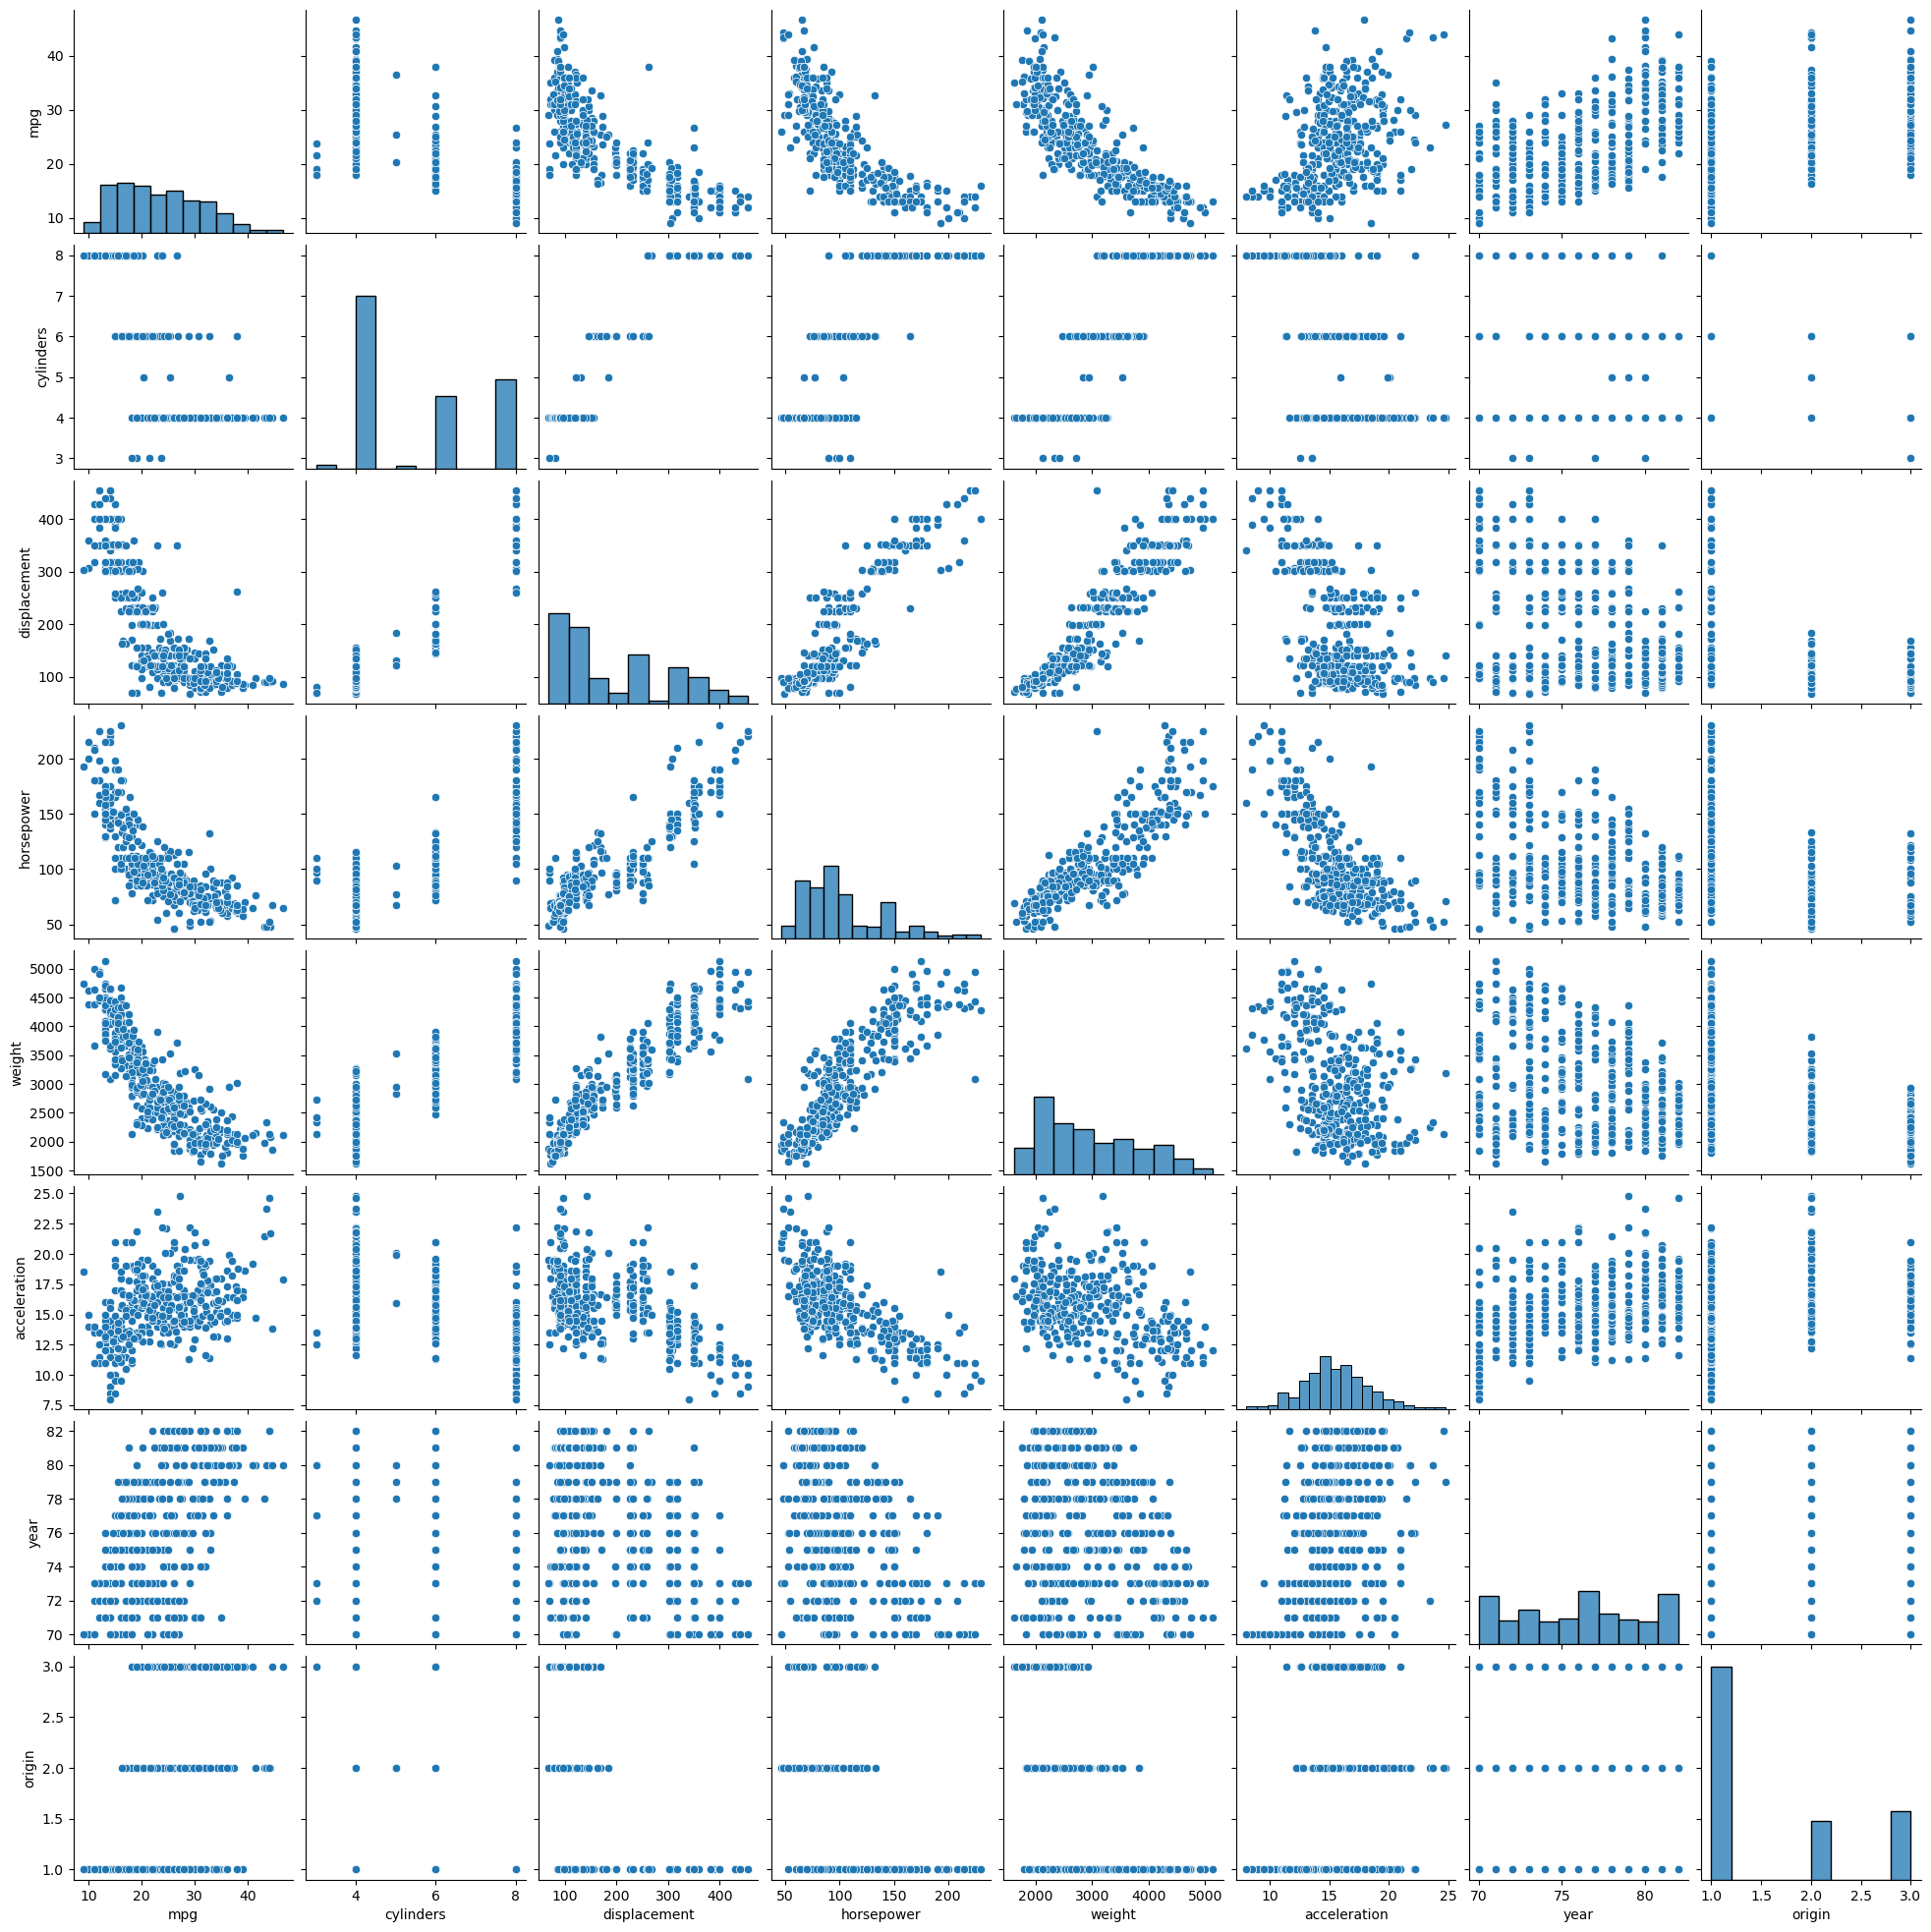

In [14]:
sns.pairplot(Auto)
plt.show()

- The scatterplots show a strong negative relationship between mpg and variables such as horsepower, weight, and displacement. This relationship is intuitive, as heavier and more powerful vehicles generally consume more fuel, resulting in lower fuel efficiency.

- An interesting relationship is observed between horsepower and acceleration. At first glance, the negative correlation appears counterintuitive because more powerful cars are expected to accelerate better. However, in the Auto dataset, the acceleration variable represents the time (in seconds) required to accelerate from 0 to 60 mph rather than the rate of acceleration itself. Consequently, vehicles with higher horsepower typically require less time to reach 60 mph, producing the observed negative correlation.

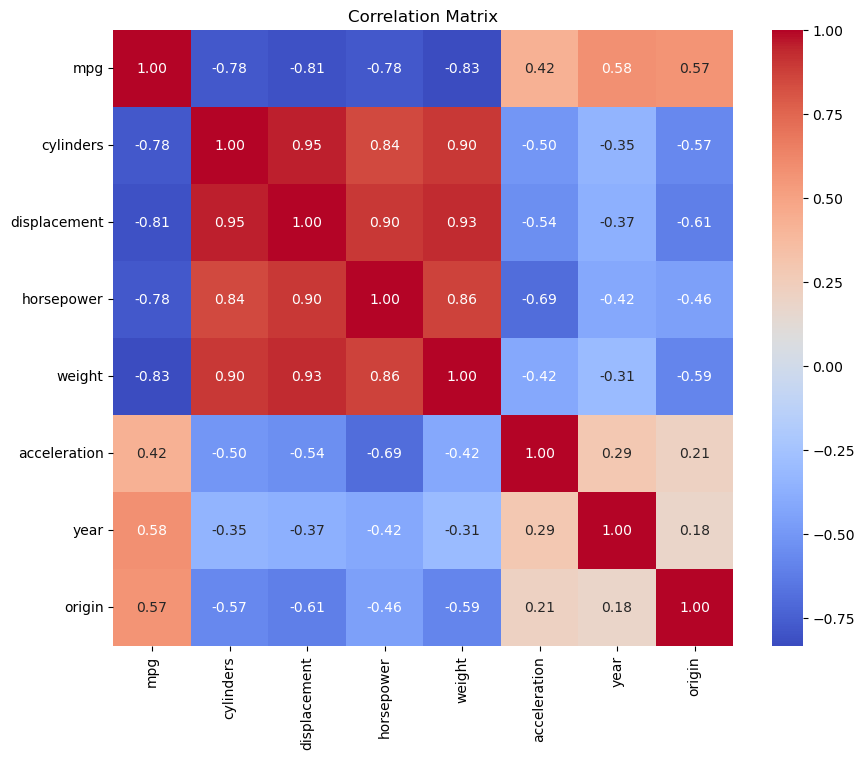

In [15]:
corr_matrix = Auto.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

The correlation matrix supports these observations. Darker red colours indicate strong positive correlations, whereas darker blue colours indicate strong negative correlations. There is also a possibility of potential multicollinearity among the predictors.

In [16]:
model = smf.ols(
    "mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin",
    data=Auto
).fit()

print(model.summary())

print("\nANOVA Table\n")
print(anova_lm(model))

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Fri, 24 Jul 2026   Prob (F-statistic):          2.04e-139
Time:                        13:38:24   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -17.2184      4.644     -3.707   

- The multiple linear regression model explains approximately 82.1% of the variation in fuel efficiency (R² = 0.821), representing a substantial improvement over the simple linear regression model. The overall F-test is highly significant (p < 0.001), indicating that the predictors collectively provide a statistically significant explanation of mpg.

- Among the predictors, weight, year, origin, and displacement are statistically significant, whereas cylinders, horsepower, and acceleration are not significant after controlling for the remaining variables. Although horsepower was highly significant in the simple linear regression, its significance disappears in the multiple regression due to multicollinearity with other engine-related variables such as weight, displacement, and cylinders.

- The coefficient for year (0.751) suggests that, holding all other variables constant, each one-year increase in model year is associated with an average increase of approximately 0.75 mpg, indicating that newer vehicles tend to be more fuel efficient.

- Finally, the large condition number reported by the model suggests the presence of multicollinearity, consistent with the strong correlations observed among several predictors in the correlation matrix. This may affect the stability and interpretation of individual regression coefficients.

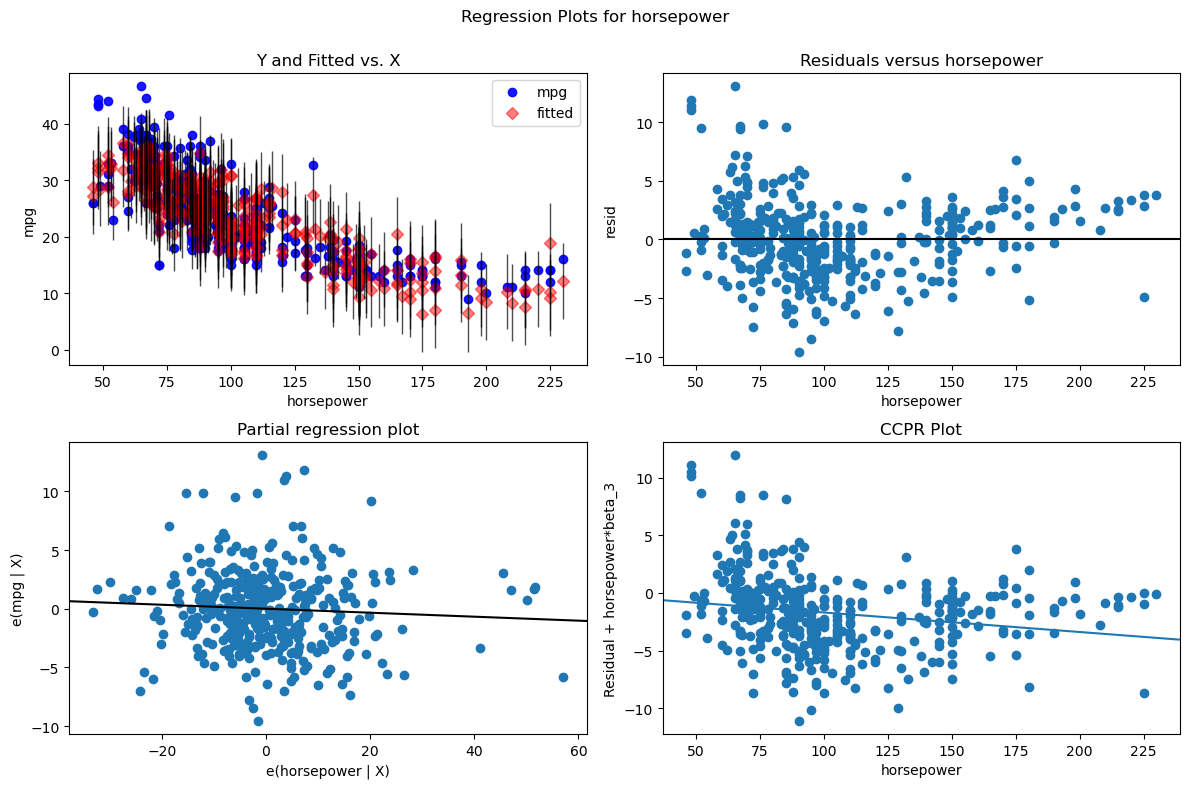

<Figure size 800x600 with 0 Axes>

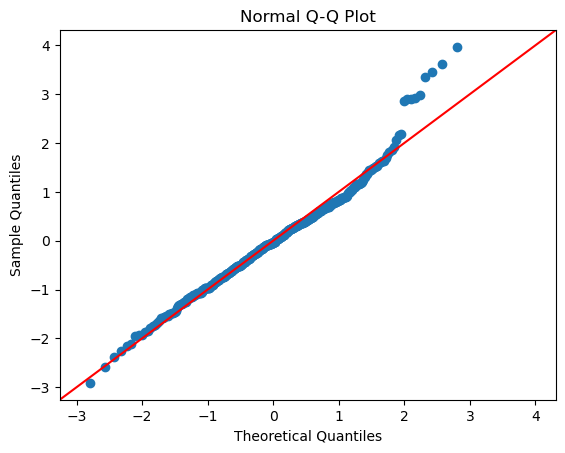

In [20]:
fig = plt.figure(figsize=(12,8))
fig = sm.graphics.plot_regress_exog(model, "horsepower", fig=fig)
plt.show()

fig = plt.figure(figsize=(8,6))
sm.qqplot(model.resid, line='45', fit=True)
plt.title("Normal Q-Q Plot")
plt.show()

- The residuals vs fitted plot still exhibits a slight systematic pattern rather than complete random scatter around zero. This suggests that the relationship between the predictors and mpg is not perfectly linear and that some model assumptions may not be fully satisfied. The remaining structure in the residuals indicates that additional nonlinear terms or interaction effects may further improve the model.
- The majority of the residuals lie close to the 45° reference line, indicating that the normality assumption is reasonably satisfied. However, the upper tail deviates noticeably above the reference line, suggesting heavier than normal tails and the presence of a few potential outliers.

In [18]:
interaction_model = smf.ols(
    "mpg ~ horsepower * weight + year + origin",
    data=Auto
).fit()

print("\nInteraction Model\n")
print(interaction_model.summary())


Interaction Model

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     477.5
Date:                Fri, 24 Jul 2026   Prob (F-statistic):          8.32e-163
Time:                        13:48:28   Log-Likelihood:                -974.68
No. Observations:                 392   AIC:                             1961.
Df Residuals:                     386   BIC:                             1985.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         

The interaction between horsepower and weight is highly statistically significant (p < 0.001), suggesting that the effect of horsepower on fuel efficiency depends on vehicle weight. Including this interaction increases the model's explanatory power, indicating that the relationship between these variables is not purely additive. When the interaction term is included, the R-square value also increases by 4%.

In [19]:
Auto["log_hp"] = np.log(Auto["horsepower"])
Auto["sqrt_weight"] = np.sqrt(Auto["weight"])
Auto["hp_sq"] = Auto["horsepower"]**2

transform_model = smf.ols(
    "mpg ~ log_hp + sqrt_weight + hp_sq + year + origin",
    data=Auto
).fit()

print("\nTransformation Model\n")
print(transform_model.summary())


Transformation Model

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     466.5
Date:                Fri, 24 Jul 2026   Prob (F-statistic):          3.92e-161
Time:                        13:48:28   Log-Likelihood:                -978.59
No. Observations:                 392   AIC:                             1969.
Df Residuals:                     386   BIC:                             1993.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      45.6166     

- Applying logarithmic, square-root, and quadratic transformations further improves the model compared with the original multiple linear regression. The transformed model achieves an R² of 0.858, which is substantially higher than the original model and only slightly lower than the interaction model. All transformed variables are statistically significant (p < 0.001), suggesting that nonlinear transformations capture relationships that are not adequately represented by a purely linear model.
- Also, values of Omnibus and JB decreases from the original model suggesting the residuals are closer to normal than before.

# Applied Exercise 10 - Multiple Linear Regression on Carseats Dataset

#### Objective - perform a multiple linear regression using the Carseats dataset.

The goal is to predict `Sales` using the regression model with multiple predictors.

In [4]:
Carseats = load_data("Carseats")

print(Carseats.head())
print(Carseats.info())

   Sales  CompPrice  Income  Advertising  Population  Price ShelveLoc  Age  \
0   9.50        138      73           11         276    120       Bad   42   
1  11.22        111      48           16         260     83      Good   65   
2  10.06        113      35           10         269     80    Medium   59   
3   7.40        117     100            4         466     97    Medium   55   
4   4.15        141      64            3         340    128       Bad   38   

   Education Urban   US  
0         17   Yes  Yes  
1         10   Yes  Yes  
2         12   Yes  Yes  
3         14   Yes  Yes  
4         13   Yes   No  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Sales        400 non-null    float64 
 1   CompPrice    400 non-null    int64   
 2   Income       400 non-null    int64   
 3   Advertising  400 non-null    int64   
 4   Populat

In [5]:
model = smf.ols(
    "Sales ~ Price + Urban + US",
    data=Carseats
).fit()

print("\nFull Model\n")
print(model.summary())


Full Model

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           2.39e-23
Time:                        23:10:02   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.0435      0.651 

In [6]:
print("\nRegression Equation\n")

print(f"Sales = {model.params['Intercept']:.4f}"
      f" + ({model.params['Price']:.4f})*Price"
      f" + ({model.params['Urban[T.Yes]']:.4f})*Urban_Yes"
      f" + ({model.params['US[T.Yes]']:.4f})*US_Yes")


Regression Equation

Sales = 13.0435 + (-0.0545)*Price + (-0.0219)*Urban_Yes + (1.2006)*US_Yes


- Intercept (13.04): The expected sales when Price = 0, Urban = No, and US = No. Since a price of 0 is unrealistic, the intercept has little practical interpretation.
- Price (-0.0545): Holding all other variables constant, a one-unit increase in price is associated with an average decrease of approximately 0.055 units in sales.
- Urban (Yes) (-0.0219): Holding price and US status constant, stores located in urban areas sell approximately 0.022 fewer units than stores in non-urban areas. However, this effect is not statistically significant (p = 0.936).
- US (Yes) (1.2006): Holding price and urban status constant, stores located in the US sell approximately 1.20 more units than stores outside the US, on average.

In [7]:
reduced_model = smf.ols(
    "Sales ~ Price + US",
    data=Carseats
).fit()

print("\nReduced Model\n")
print(reduced_model.summary())


Reduced Model

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           2.66e-24
Time:                        23:11:32   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.0308      0.631    

In [8]:
print("\nModel Comparison")

comparison = pd.DataFrame({
    "Model": ["Full", "Reduced"],
    "R_squared": [model.rsquared, reduced_model.rsquared],
    "Adj_R_squared": [model.rsquared_adj, reduced_model.rsquared_adj],
    "AIC": [model.aic, reduced_model.aic],
    "BIC": [model.bic, reduced_model.bic]
})

print(comparison)


Model Comparison
     Model  R_squared  Adj_R_squared          AIC          BIC
0     Full   0.239275       0.233512  1863.312074  1879.277932
1  Reduced   0.239263       0.235430  1861.318648  1873.293042


An interesting thing to note here is that the reduced model performs even better. Although variables provide some information and reduce the error, AIC and BIC penalise more features. Hence, the model with less features but a similar/less error is rewarded.

In [9]:
print("\n95% Confidence Intervals\n")
print(reduced_model.conf_int())


95% Confidence Intervals

                  0          1
Intercept  11.79032  14.271265
US[T.Yes]   0.69152   1.707766
Price      -0.06476  -0.044195


We are 95% confident that increasing the price by one unit decreases average sales by between approximately 0.044 and 0.065 units, holding the other predictors constant.
We are 95% confident that increasing the unit sold in the US increases average sales by between approximately 0.069 and 1.708 units, holding the other predictors constant.

<Figure size 400x600 with 0 Axes>

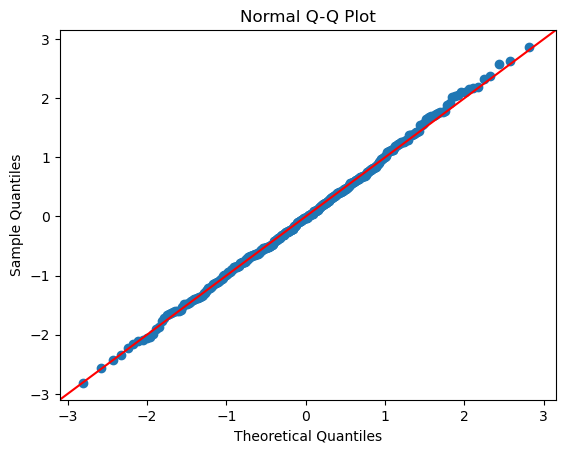

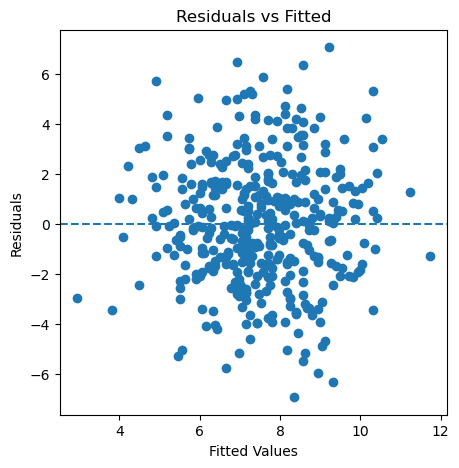

In [14]:
fig = plt.figure(figsize=(4,6))
sm.qqplot(reduced_model.resid, line="45", fit=True)
plt.title("Normal Q-Q Plot")
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(reduced_model.fittedvalues, reduced_model.resid)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

- The Q-Q plot closely follows the 45° reference line, indicating that the residuals are approximately normally distributed and that the normality assumption is well satisfied.

- The residuals versus fitted values plot shows a random scatter around zero with no obvious systematic pattern or funnel shape. This suggests that the assumptions of linearity and constant variance are reasonably satisfied.

- The multiple regression analysis indicates that Price and US are significant predictors of sales, whereas Urban is not. Removing the insignificant predictor results in a simpler model with nearly identical explanatory power and slightly improved model selection criteria (AIC and BIC). The reduced model provides a parsimonious and adequate fit to the data.

# Applied Exercise 11 - Investigating the t-Statistic in Simple Linear Regression

#### Objective - To investigate the behaviour of the t-statistic for testing H_0: β=0 when performing simple linear regression **without an intercept**.

In [3]:
rng = np.random.default_rng(1)

x = rng.normal(size=100)
y = 2 * x + rng.normal(size=100)

In [4]:
model_yx = sm.OLS(y, x).fit()

print("="*60)
print("Regression of y on x (No Intercept)")
print("="*60)

print(model_yx.summary())

Regression of y on x (No Intercept)
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.743
Model:                            OLS   Adj. R-squared (uncentered):              0.740
Method:                 Least Squares   F-statistic:                              285.6
Date:                Sun, 26 Jul 2026   Prob (F-statistic):                    6.23e-31
Time:                        10:03:53   Log-Likelihood:                         -141.35
No. Observations:                 100   AIC:                                      284.7
Df Residuals:                      99   BIC:                                      287.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----

The estimated slope coefficient is 1.9762, which is very close to the true coefficient of 2 used to generate the data (y = 2x + ε). The standard error is 0.1169, indicating that the estimate is reasonably precise. The t-statistic (16.90) is extremely large, and the associated p-value is effectively zero (p < 0.001). Therefore, we reject the null hypothesis H0: β=0 and conclude that there is a statistically significant positive linear relationship between x and y.

In [5]:
model_xy = sm.OLS(x, y).fit()

print("="*60)
print("Regression of x on y (No Intercept)")
print("="*60)

print(model_xy.summary())

Regression of x on y (No Intercept)
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.743
Model:                            OLS   Adj. R-squared (uncentered):              0.740
Method:                 Least Squares   F-statistic:                              285.6
Date:                Sun, 26 Jul 2026   Prob (F-statistic):                    6.23e-31
Time:                        10:03:53   Log-Likelihood:                         -58.349
No. Observations:                 100   AIC:                                      118.7
Df Residuals:                      99   BIC:                                      121.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----

- Regressing x on y produces a different slope estimate (0.3757) because the response and predictor variables have been exchanged. However, the standard error, t-statistic (16.90), and p-value remain identical to those obtained in part (a). Thus, both regressions lead to the same conclusion regarding the statistical significance of the relationship.
- Although the estimated regression coefficients differ because the response and predictor variables have been reversed, both regressions produce exactly the same t-statistic and p-value. Consequently, both models provide identical evidence against the null hypothesis that the slope is zero.

In [6]:
beta_hat = np.sum(x * y) / np.sum(x**2)

SSE = np.sum((y - beta_hat * x)**2)

SE = np.sqrt((SSE / (len(x)-1)) / np.sum(x**2))

t_manual = beta_hat / SE

print("="*60)
print("Manual Computation")
print("="*60)

print(f"Beta_hat : {beta_hat:.6f}")
print(f"Standard Error : {SE:.6f}")
print(f"Manual t-statistic : {t_manual:.6f}")
print(f"Statsmodels t-statistic : {model_yx.tvalues[0]:.6f}")

Manual Computation
Beta_hat : 1.976242
Standard Error : 0.116948
Manual t-statistic : 16.898417
Statsmodels t-statistic : 16.898417


In [7]:
n = len(x)

numerator = np.sqrt(n-1) * np.sum(x*y)

denominator = np.sqrt(
    np.sum(x**2)*np.sum(y**2) -
    (np.sum(x*y))**2
)

t_formula = numerator / denominator

print(f"Closed-form t-statistic : {t_formula:.6f}")

Closed-form t-statistic : 16.898417


The closed-form expression for the t-statistic is symmetric in the variables $x$ and $y$. Consequently, the numerator and denominator of the expression remain unchanged, implying that the t-statistic is identical regardless of whether the regression is performed as $y$ on $x$ or $x$ on $y$.

This is confirmed numerically, as both regressions produced the same t-statistic of **16.8984**.

In [9]:
X = sm.add_constant(x)
Y = sm.add_constant(y)

model1 = sm.OLS(y, X).fit()
model2 = sm.OLS(x, Y).fit()

print("="*60)
print("Regression WITH Intercept")
print("="*60)

print(f"t-statistic (y ~ x): {model1.tvalues[1]:.6f}")
print(f"t-statistic (x ~ y): {model2.tvalues[1]:.6f}")

Regression WITH Intercept
t-statistic (y ~ x): 16.734055
t-statistic (x ~ y): 16.734055


The regressions were repeated after including an intercept term. The intercept term even though not zero, has a very high p value making it statistically insignificant. Hence, the null hypothesis of H0: β = 0 cannot be rejected.

# Applied Exercise 12 - Regression Without an Intercept

#### Objectiveis to investigates when the slope estimates obtained from regressing $Y$ on $X$ and $X$ on $Y$ (without an intercept) are identical.

In [3]:
rng = np.random.default_rng(10)

x = rng.normal(size=100)
y = 3*x + rng.normal(size=100)

model_yx = sm.OLS(y, x).fit()
model_xy = sm.OLS(x, y).fit()

print("="*60)
print("(b) Different Coefficients")
print("="*60)

print(f"Slope (y on x): {model_yx.params[0]:.6f}")
print(f"Slope (x on y): {model_xy.params[0]:.6f}")

(b) Different Coefficients
Slope (y on x): 3.104126
Slope (x on y): 0.274256


In [4]:
rng = np.random.default_rng(20)
x = rng.normal(size=100)

# y = x (Works when y=-x)
y = x.copy()

model_yx = sm.OLS(y, x).fit()
model_xy = sm.OLS(x, y).fit()

print("\n" + "="*60)
print("(c) Equal Coefficients")
print("="*60)

print(f"Slope (y on x): {model_yx.params[0]:.6f}")
print(f"Slope (x on y): {model_xy.params[0]:.6f}")


(c) Equal Coefficients
Slope (y on x): 1.000000
Slope (x on y): 1.000000



For regression without an intercept, the two coefficient estimates are equal only when

$$
\sum x_i^2=\sum y_i^2.
$$

This means that the total sum of squares of the predictor and response variables must be identical. A simple example is when y=x or y=-x since both variables then have the same sum of squared values.